# Example 3: Many-body state transfer

Authors: C. Ventura-Meinersen and D. Fernandez-Fernandez

Below we import the necesary libraries for this example file:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from parameterrun import parameterrun

import geodesiq as gq

# Ising spin chain (with QuSpin)

We want to prepare the ground state of a many-body Hamiltonian. Here, we focus on the Ising spin chain with local fields in $\sigma^x_j$ and $\sigma^z_j$ directions on each site $j$. The model (with open boundary conditions) is given by
$$\hat{H}/J=\lambda(t)\hat{H}_\text{target}+(1-\lambda(t))\hat{H}_\text{init}=\lambda(t)\left[\sum_{j=1}^{L-1} \,\sigma_j^z\sigma_{j+1}^z +\sum_{j=1}^Lh_z\,\sigma_z\right]+ \Big(1-\lambda(t)\Big)\sum_{j=1}^L h_x\,\sigma_j^x$$
where $(h_x,h_z)$ parametrize the strengths of the external fields and $\lambda(t)$ is the control field. We aim to prepare the interacting ground state of the Ising model by initializing the ground state of $\hat{H}_\text{init}$, which is the state $\ket{\psi_0[\lambda(0)]}=\ket{+}^{\otimes L}$, and then sweeping the control field from $\lambda(0)=0$ to $\lambda(t_\text{f})=1$.

To prepare the many-body spin chain Hamiltonian, we make use of the `quspin` Python package to efficiently generate the Ising spin chain. For more details on `quspin` check out their documentation. 

In [2]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian


def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


# ----- Set system and control parameters -----
alpha, beta = 2, 2
initial_state = 0

L, hx, hz = 7, 1, 0.8
lam0, lamf = 0, 1

H_d = ising_model(0, L, hx, hz)
H_c = ising_model(1, L, hx, hz) - H_d

# ising = gq.ControlModel(ising_model)
ising = gq.ControlModel(H_c=H_c, H_d=H_d)

# ising.set_parameters(L=L, hx=hx, hz=hz)
ising.set_control(
    control_name="lam",
    pulse_initial=lam0,
    pulse_final=lamf,
    initial_state=initial_state,
    alpha=alpha,
    beta=beta,
    num_steps=2**4 + 1,
)

Depending on the size of the spin chain $L$, the energy spectrum will be more and more dense, also rendering the time evolution slow.

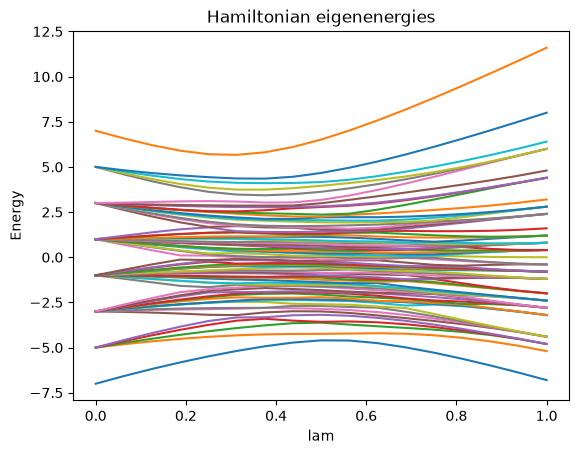

In [3]:
ising.plot_eigenvalues(legend=False);

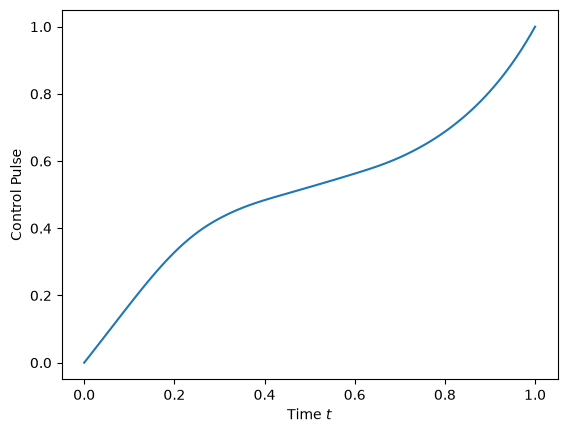

In [6]:
ising.solve_problem(pulse_accuracy=int(100))
pulse = ising.synthesize_pulse(duration=1)
pulse.plot_pulse();

# Time dependent simulations

We can check the time-evolved results for any given total pulse time. As the pulses generated by `geodesiq` can be rescaled for any total duration, we can efficiently make use of Python packages that allow for parallelization. You may use the `joblib` or the `parameterrun` Python packages to accomplish this.

In [11]:
def _worker_compute_fidelity(duration, model, psi_i, psi_t):
    dynamics = gq.Dynamics(duration=duration, model=model)
    return dynamics.state_fidelity(initial_state=psi_i, final_state=psi_t)


def fidelity_vs_time(durations, model, L, n_jobs=-1):
    H_d = ising_model(0, L, hx, hz)
    H_c = ising_model(1, L, hx, hz) - H_d

    model = gq.ControlModel(H_c=H_c, H_d=H_d)

    model.set_control(pulse_initial=lam0, pulse_final=lamf, initial_state=initial_state, alpha=alpha,
                      beta=beta, num_steps=2 ** 4 + 1)
    
    model.solve_problem(pulse_accuracy=int(100))

    _, init_eigenstates = qt.Qobj(model(lam0)).eigenstates()
    psi_init = init_eigenstates[initial_state]

    _, final_eigenstates = qt.Qobj(model(lamf)).eigenstates()
    psi_target = final_eigenstates[initial_state]

    # Run the loop in parallel with joblib
    # fidelities = Parallel(n_jobs=n_jobs)(
    #     delayed(_worker_compute_fidelity)(duration, model)
    #     for duration in tqdm(durations, desc="Computing fidelities")
    # )

    # Run the loop in parallel with parameterrun
    fidelities = parameterrun(
        _worker_compute_fidelity, "duration", durations, model=model, psi_i=psi_init, psi_t=psi_target, n_workers=n_jobs
    )

    return np.array(fidelities)

In [12]:
durations = np.linspace(0.1, 1000, 20)
fidelities_L2 = fidelity_vs_time(durations=durations, model=ising, L=2)
fidelities_L4 = fidelity_vs_time(durations=durations, model=ising, L=4)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [13]:
fidelities_L6 = fidelity_vs_time(durations=durations, model=ising, L=6)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [14]:
fidelities_L8 = fidelity_vs_time(durations=durations, model=ising, L=8)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

In [15]:
fidelities_L10 = fidelity_vs_time(durations=durations, model=ising, L=10)

_worker_compute_fidelity: [['duration']]:   0%|          | 0/20 [00:00<?, ?it/s]

We can plot the resulting fidelities of the enforced adiabatic transfer with $(\alpha,\beta)=(2,2)$

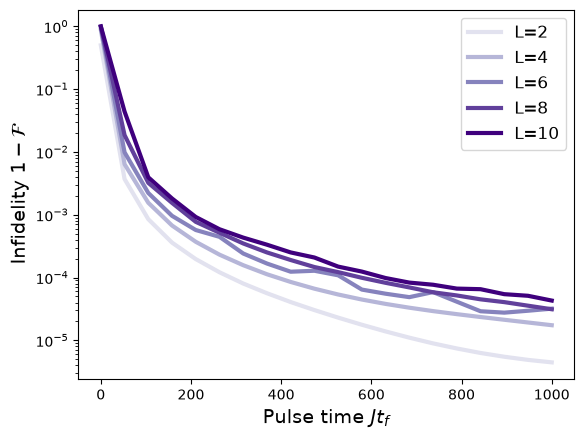

In [18]:
import matplotlib.cm as cm

L_vals = np.array([2, 4, 6, 8, 10])
norm = plt.Normalize(vmin=L_vals.min() - 2, vmax=L_vals.max())
colors_rgba = cm.Purples(norm(L_vals))

data = {"L=2": fidelities_L2, "L=4": fidelities_L4, "L=6": fidelities_L6, "L=8": fidelities_L8, "L=10": fidelities_L10}

for label, fidelities in data.items():
    plt.plot(durations, 1 - fidelities, label=label, lw=3, color=colors_rgba[int(label.split("=")[1]) // 2 - 1])

plt.yscale("log")
plt.ylabel(r"Infidelity $1-\mathcal{F}$", fontsize=14)
plt.xlabel("Pulse time $J t_f$", fontsize=14)
plt.legend(fontsize=12)
plt.show();

# About

In [19]:
gq.about()


geodesiq: geometric optimal control
Authors:            Christian Ventura Meinersen & David Fernández Fernández
geodesiq Version:   0.2.0
Python Version:     3.13.12 (cpython)
Number of CPUs:     24
Platform Info:      Linux (6.18.33.2-microsoft-standard-WSL2, x86_64)

Core Dependencies:
Numpy Version:      2.4.6
Scipy Version:      1.17.1
QuTiP Version:      5.3.0
Matplotlib Version: 3.11.0

Please cite geodesiq in your publication.
Reference paper: 
